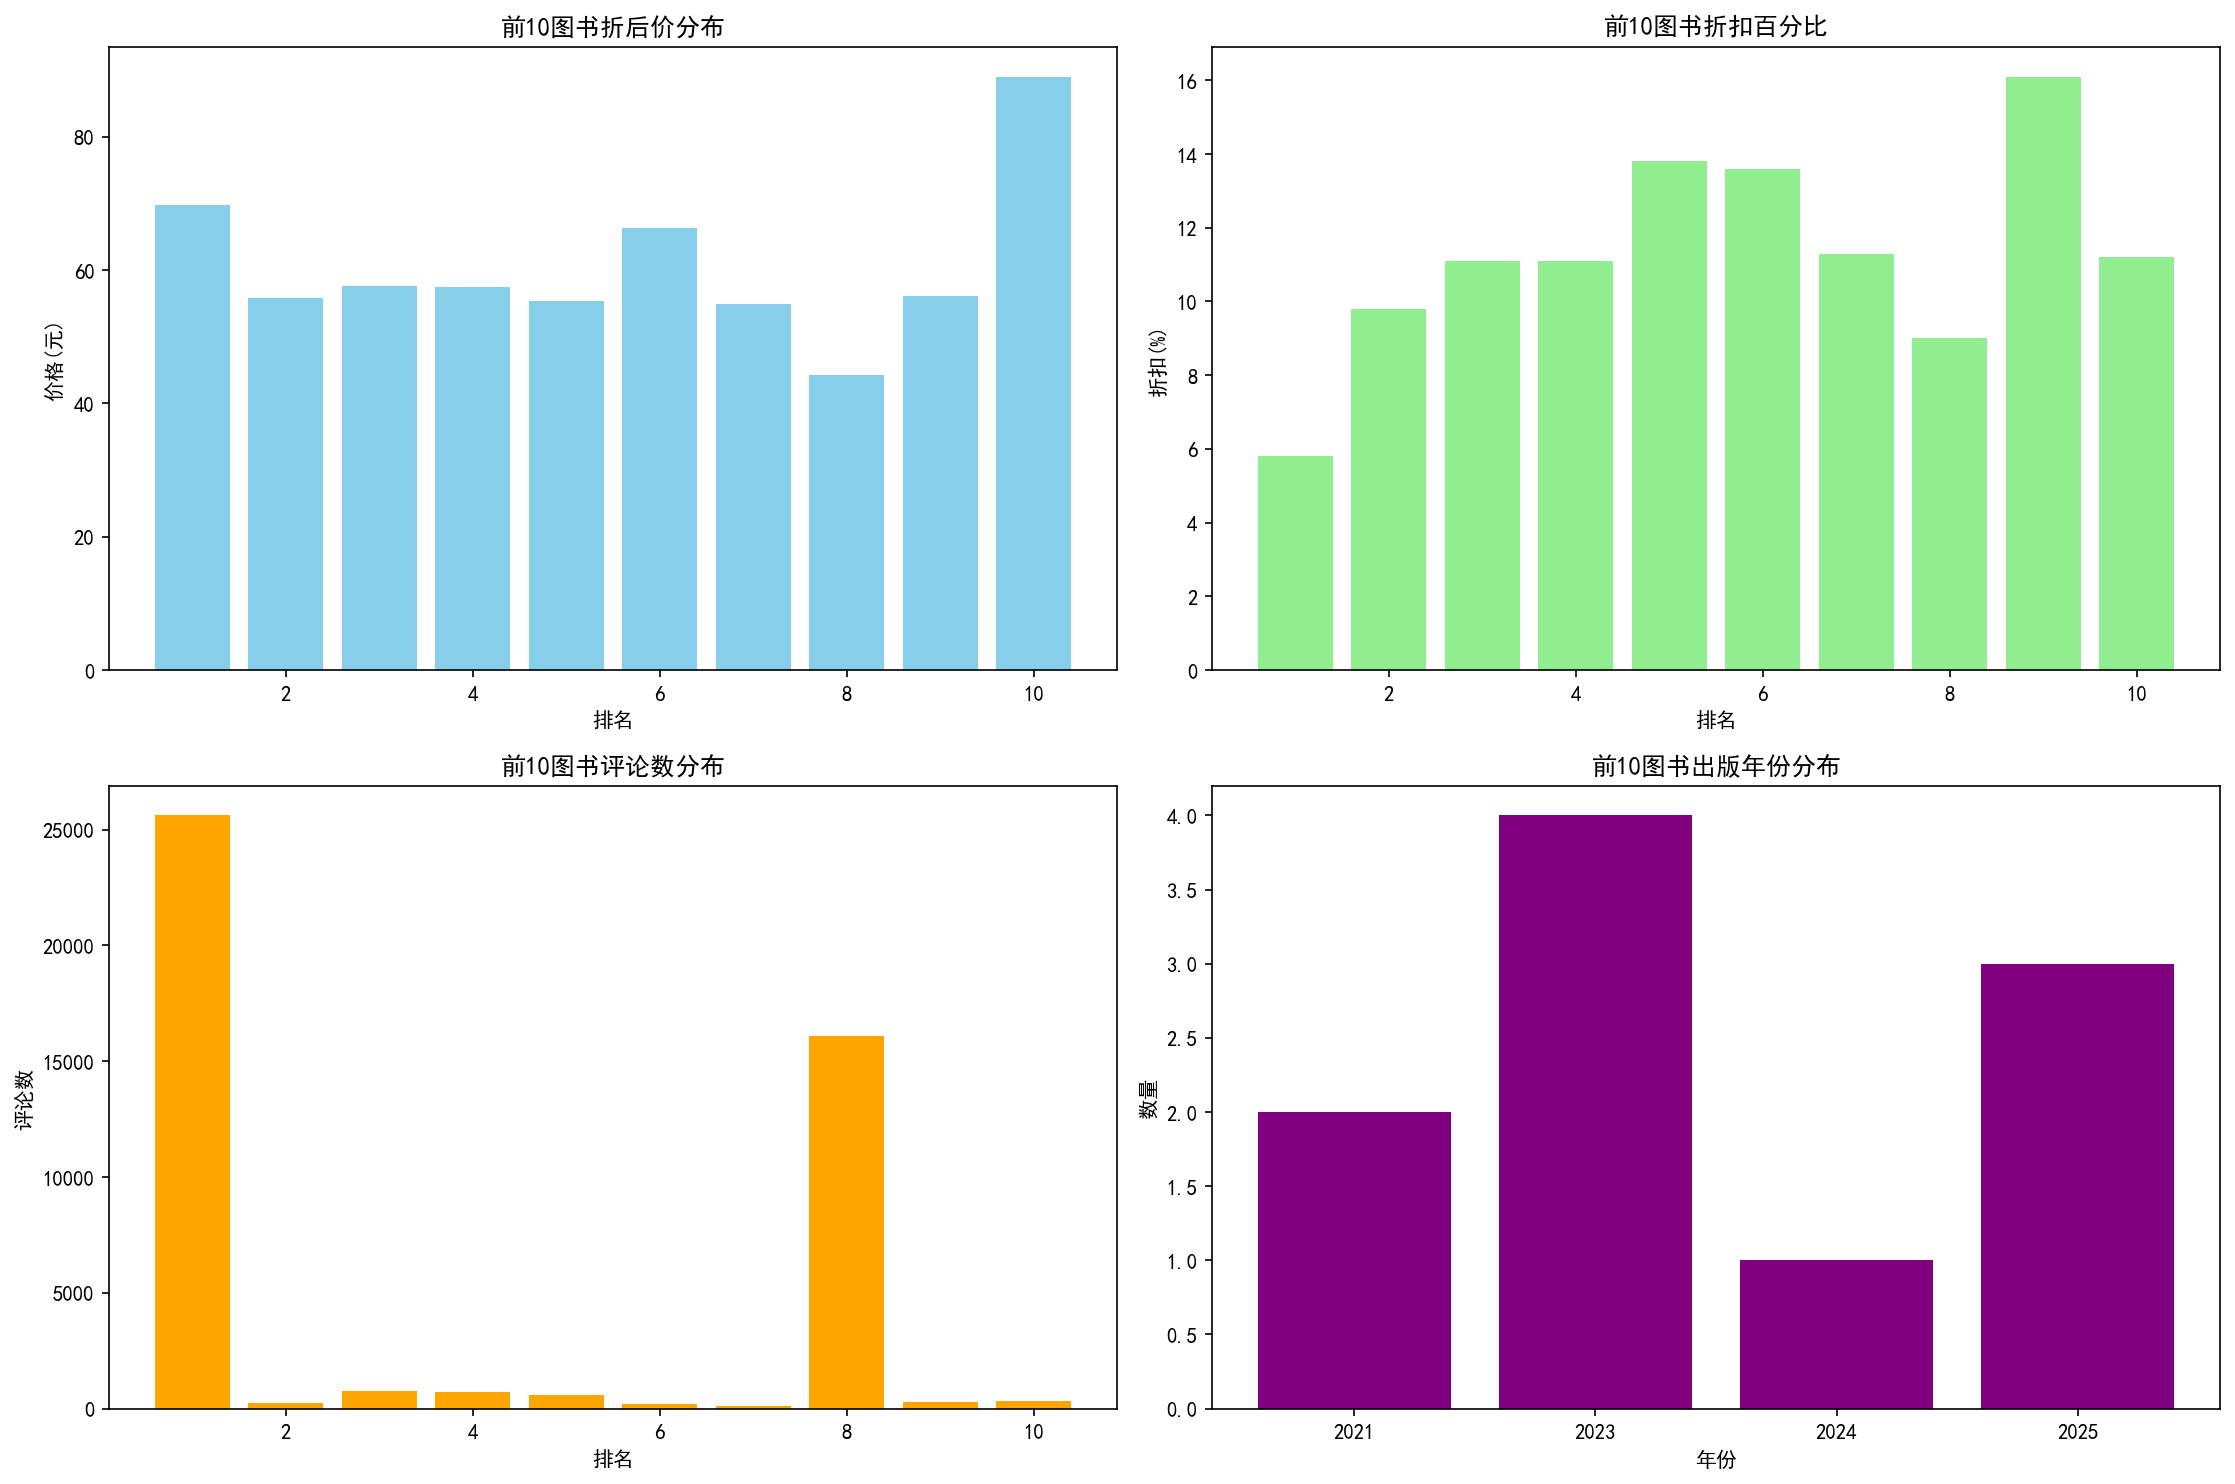

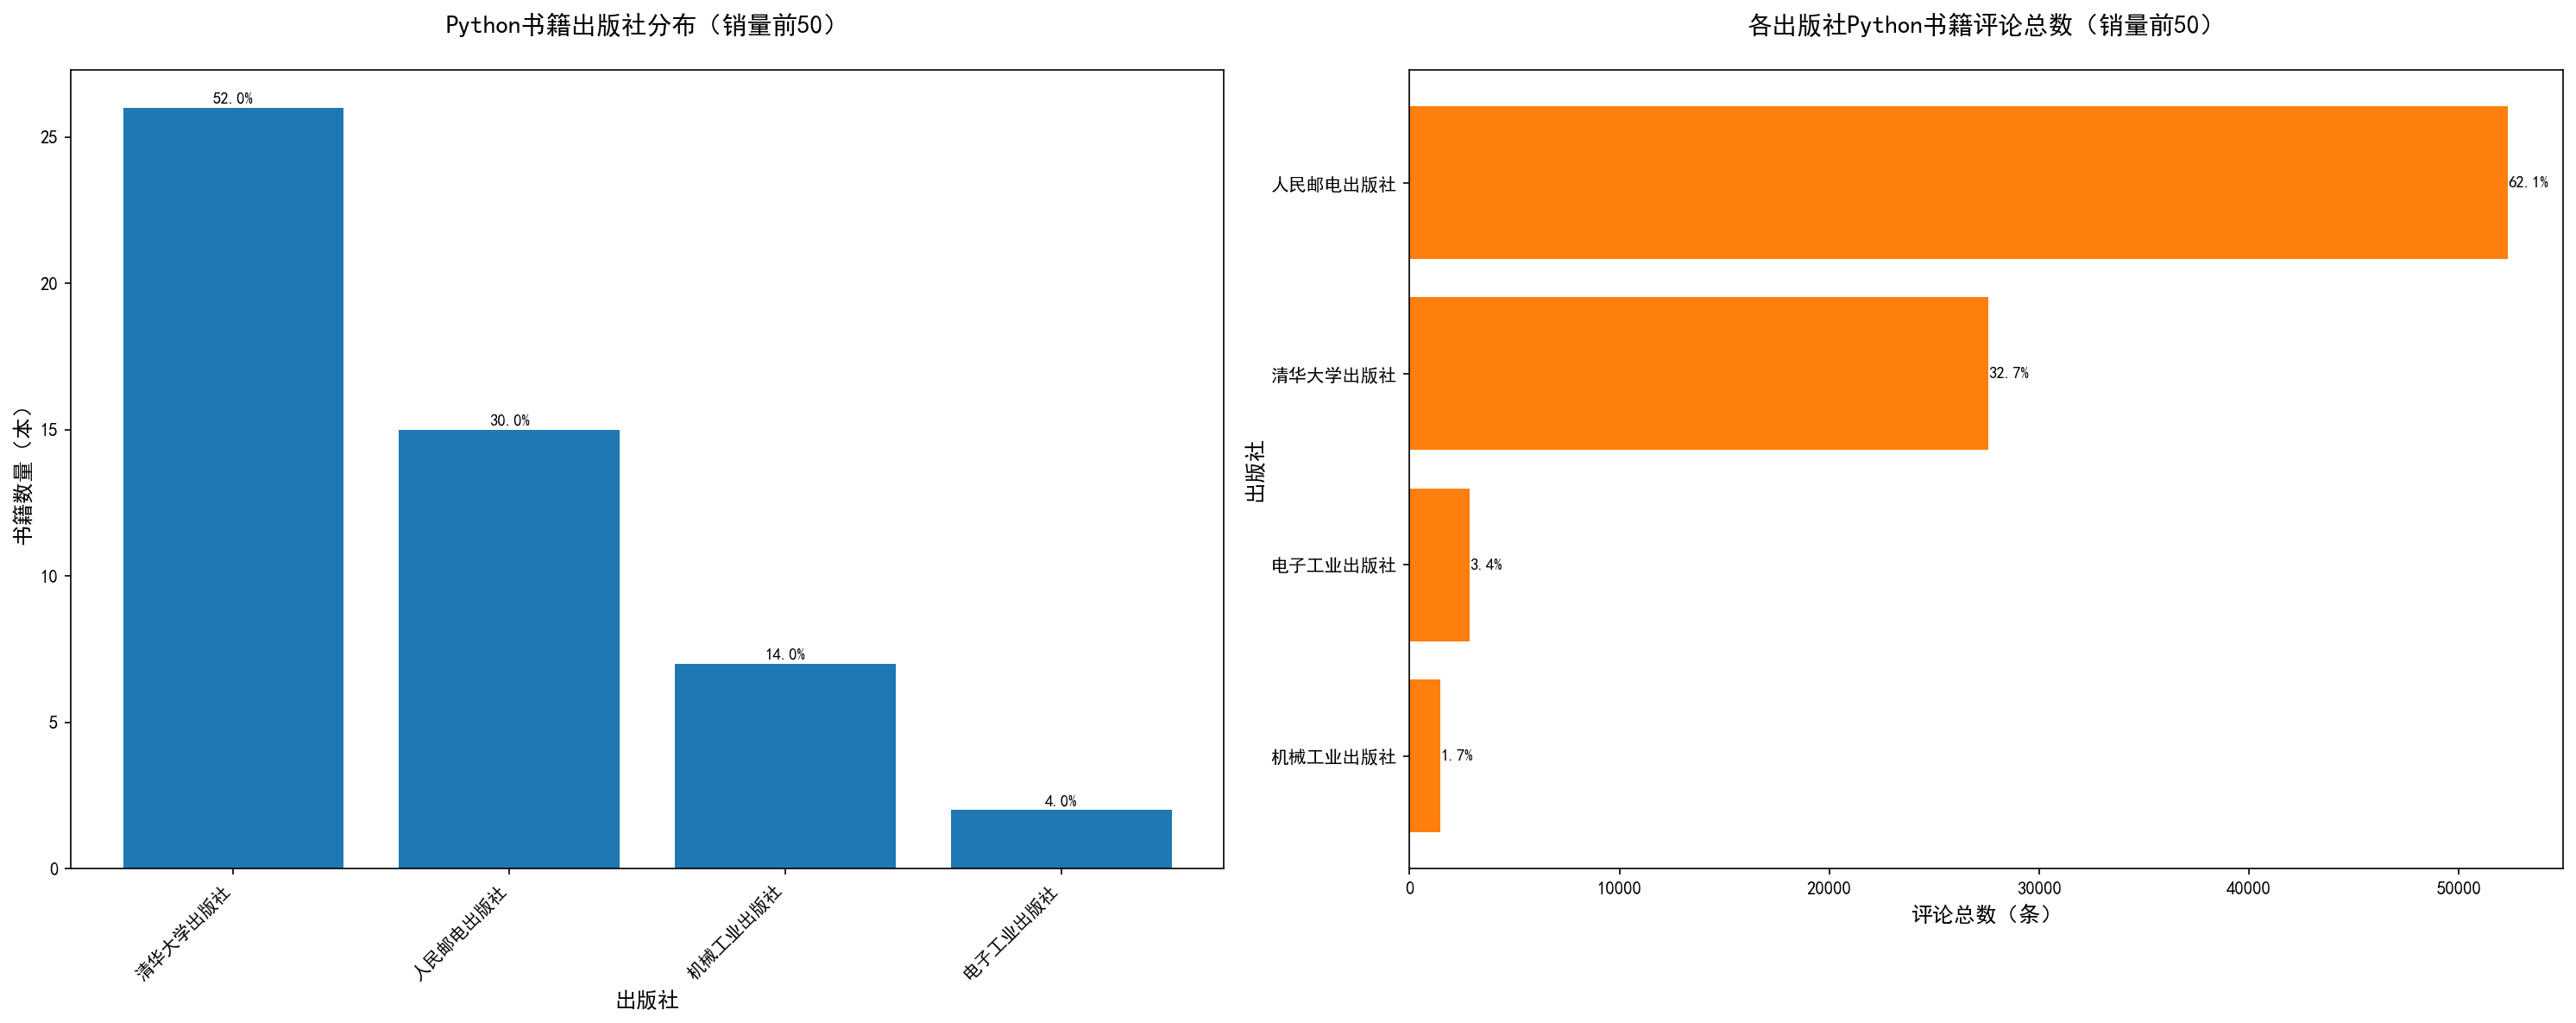

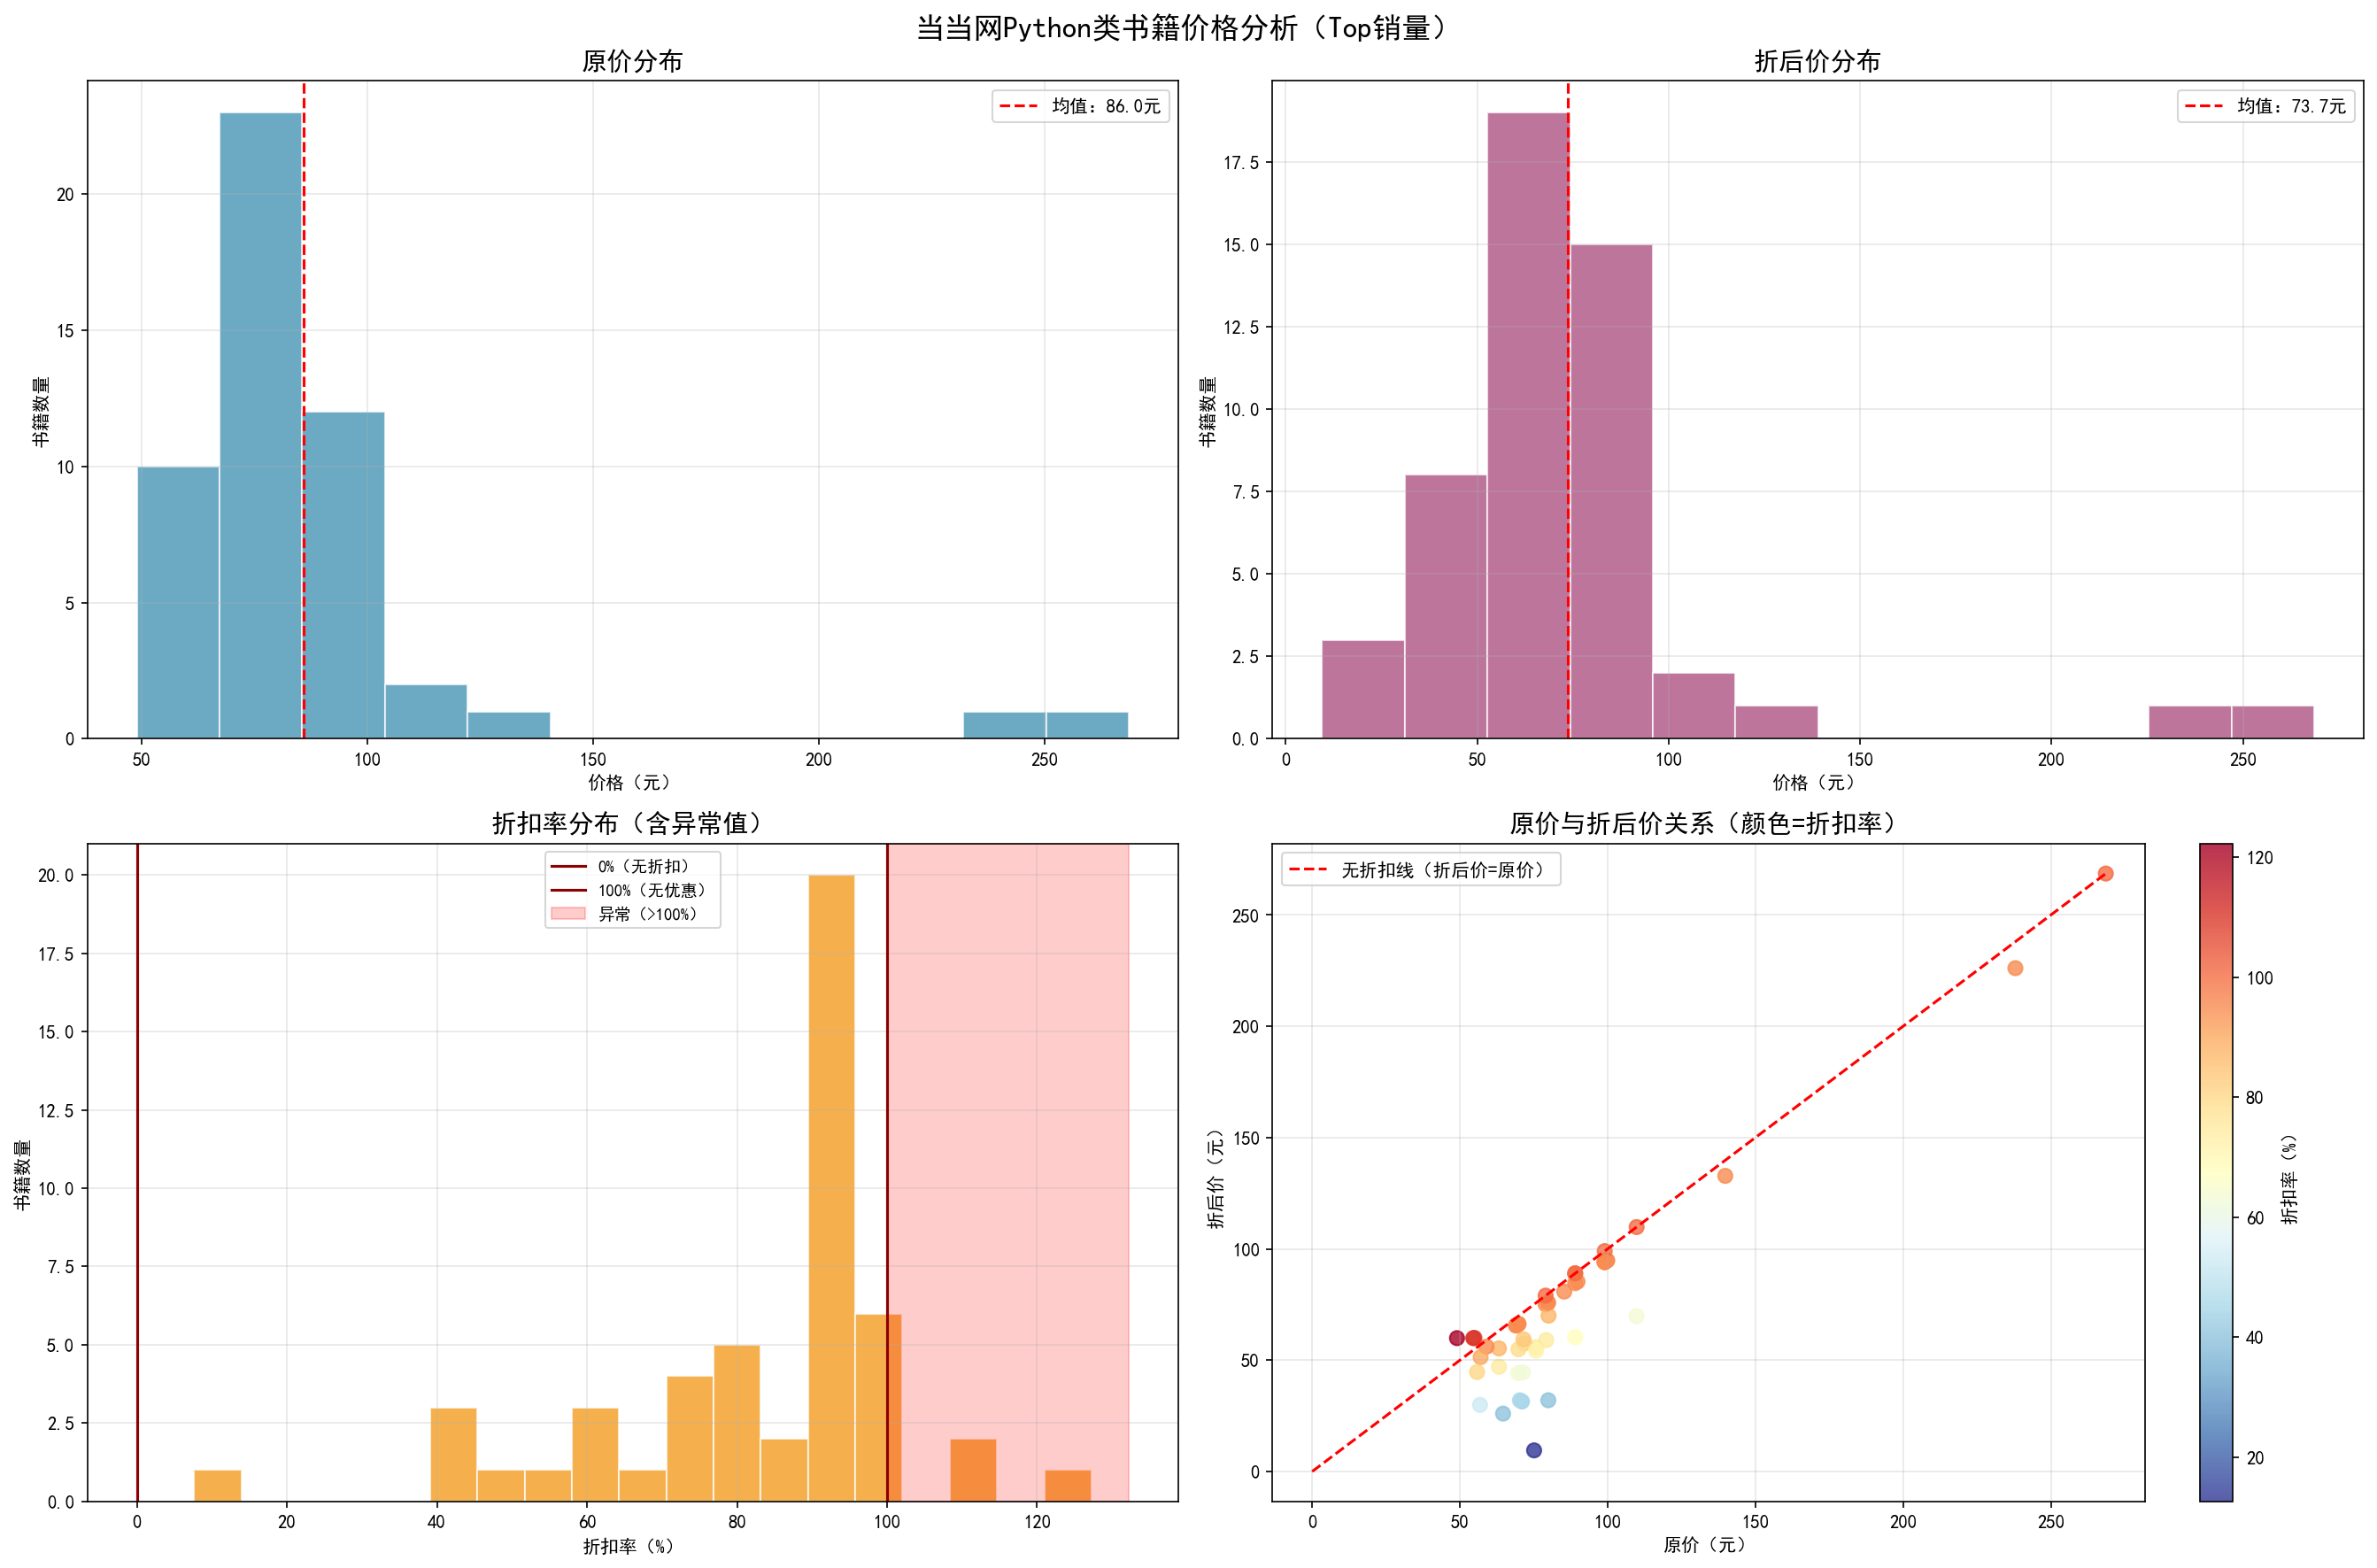

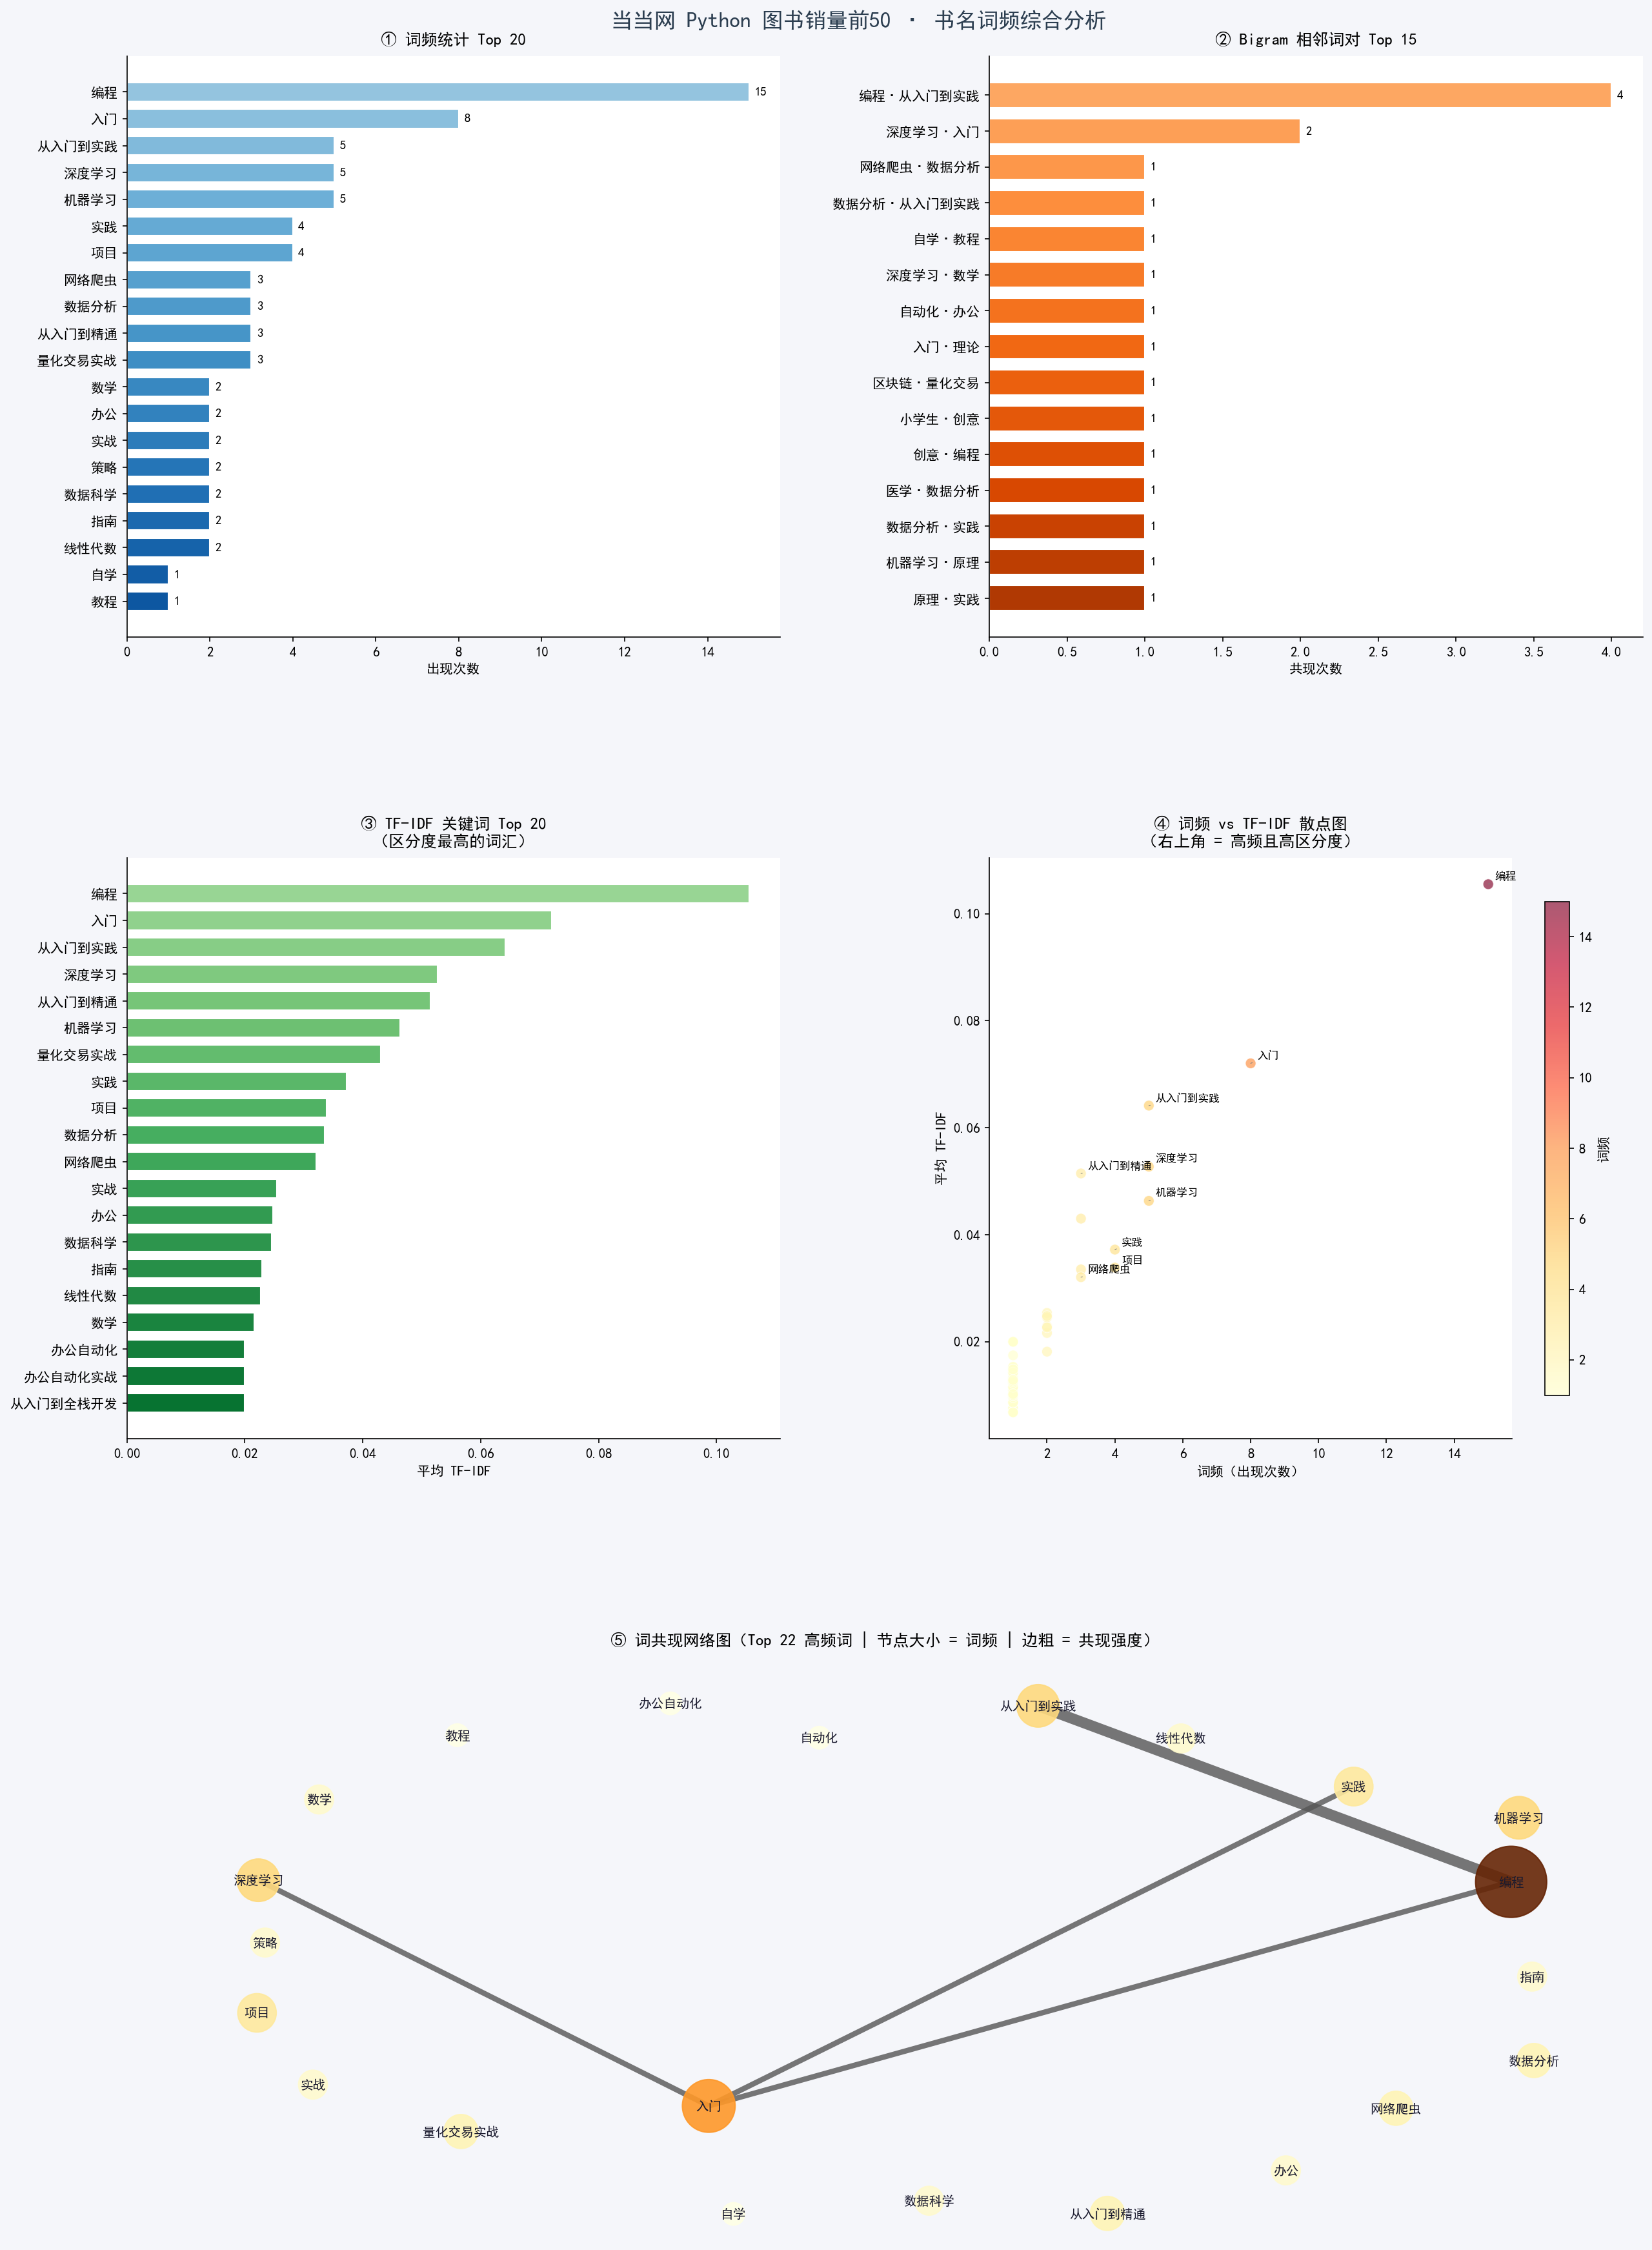

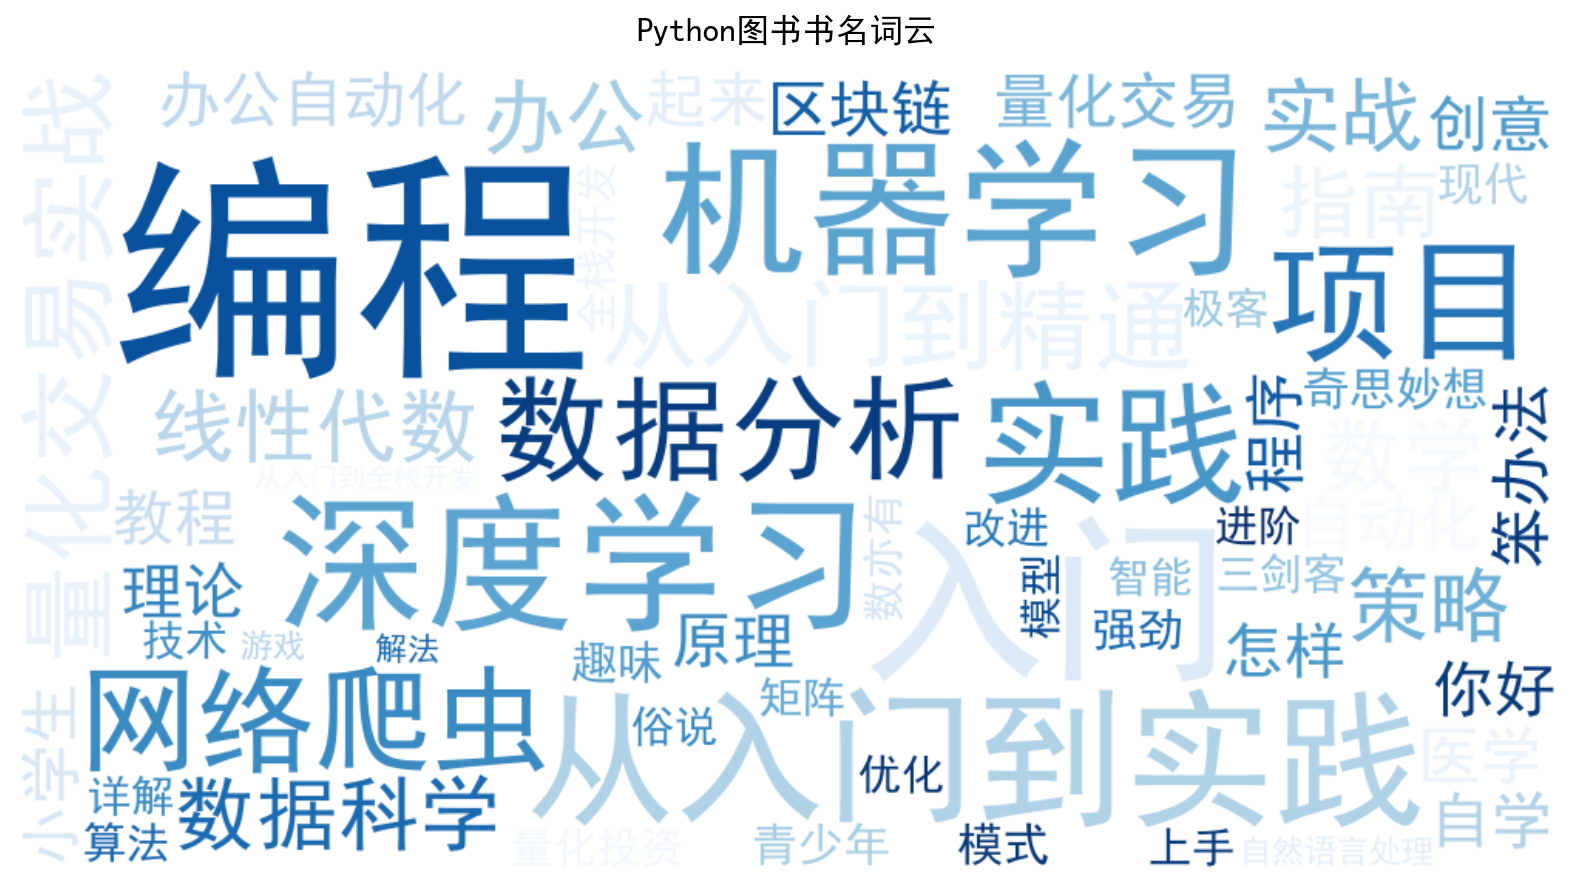

,书名,折后价,折扣,评论数
0,Python编程从入门到实践 第3版,69.80,6.4,25616
1,Python网络爬虫与数据分析从入门到实践,55.86,7.4,226
2,Python完全自学教程,57.54,8.0,780


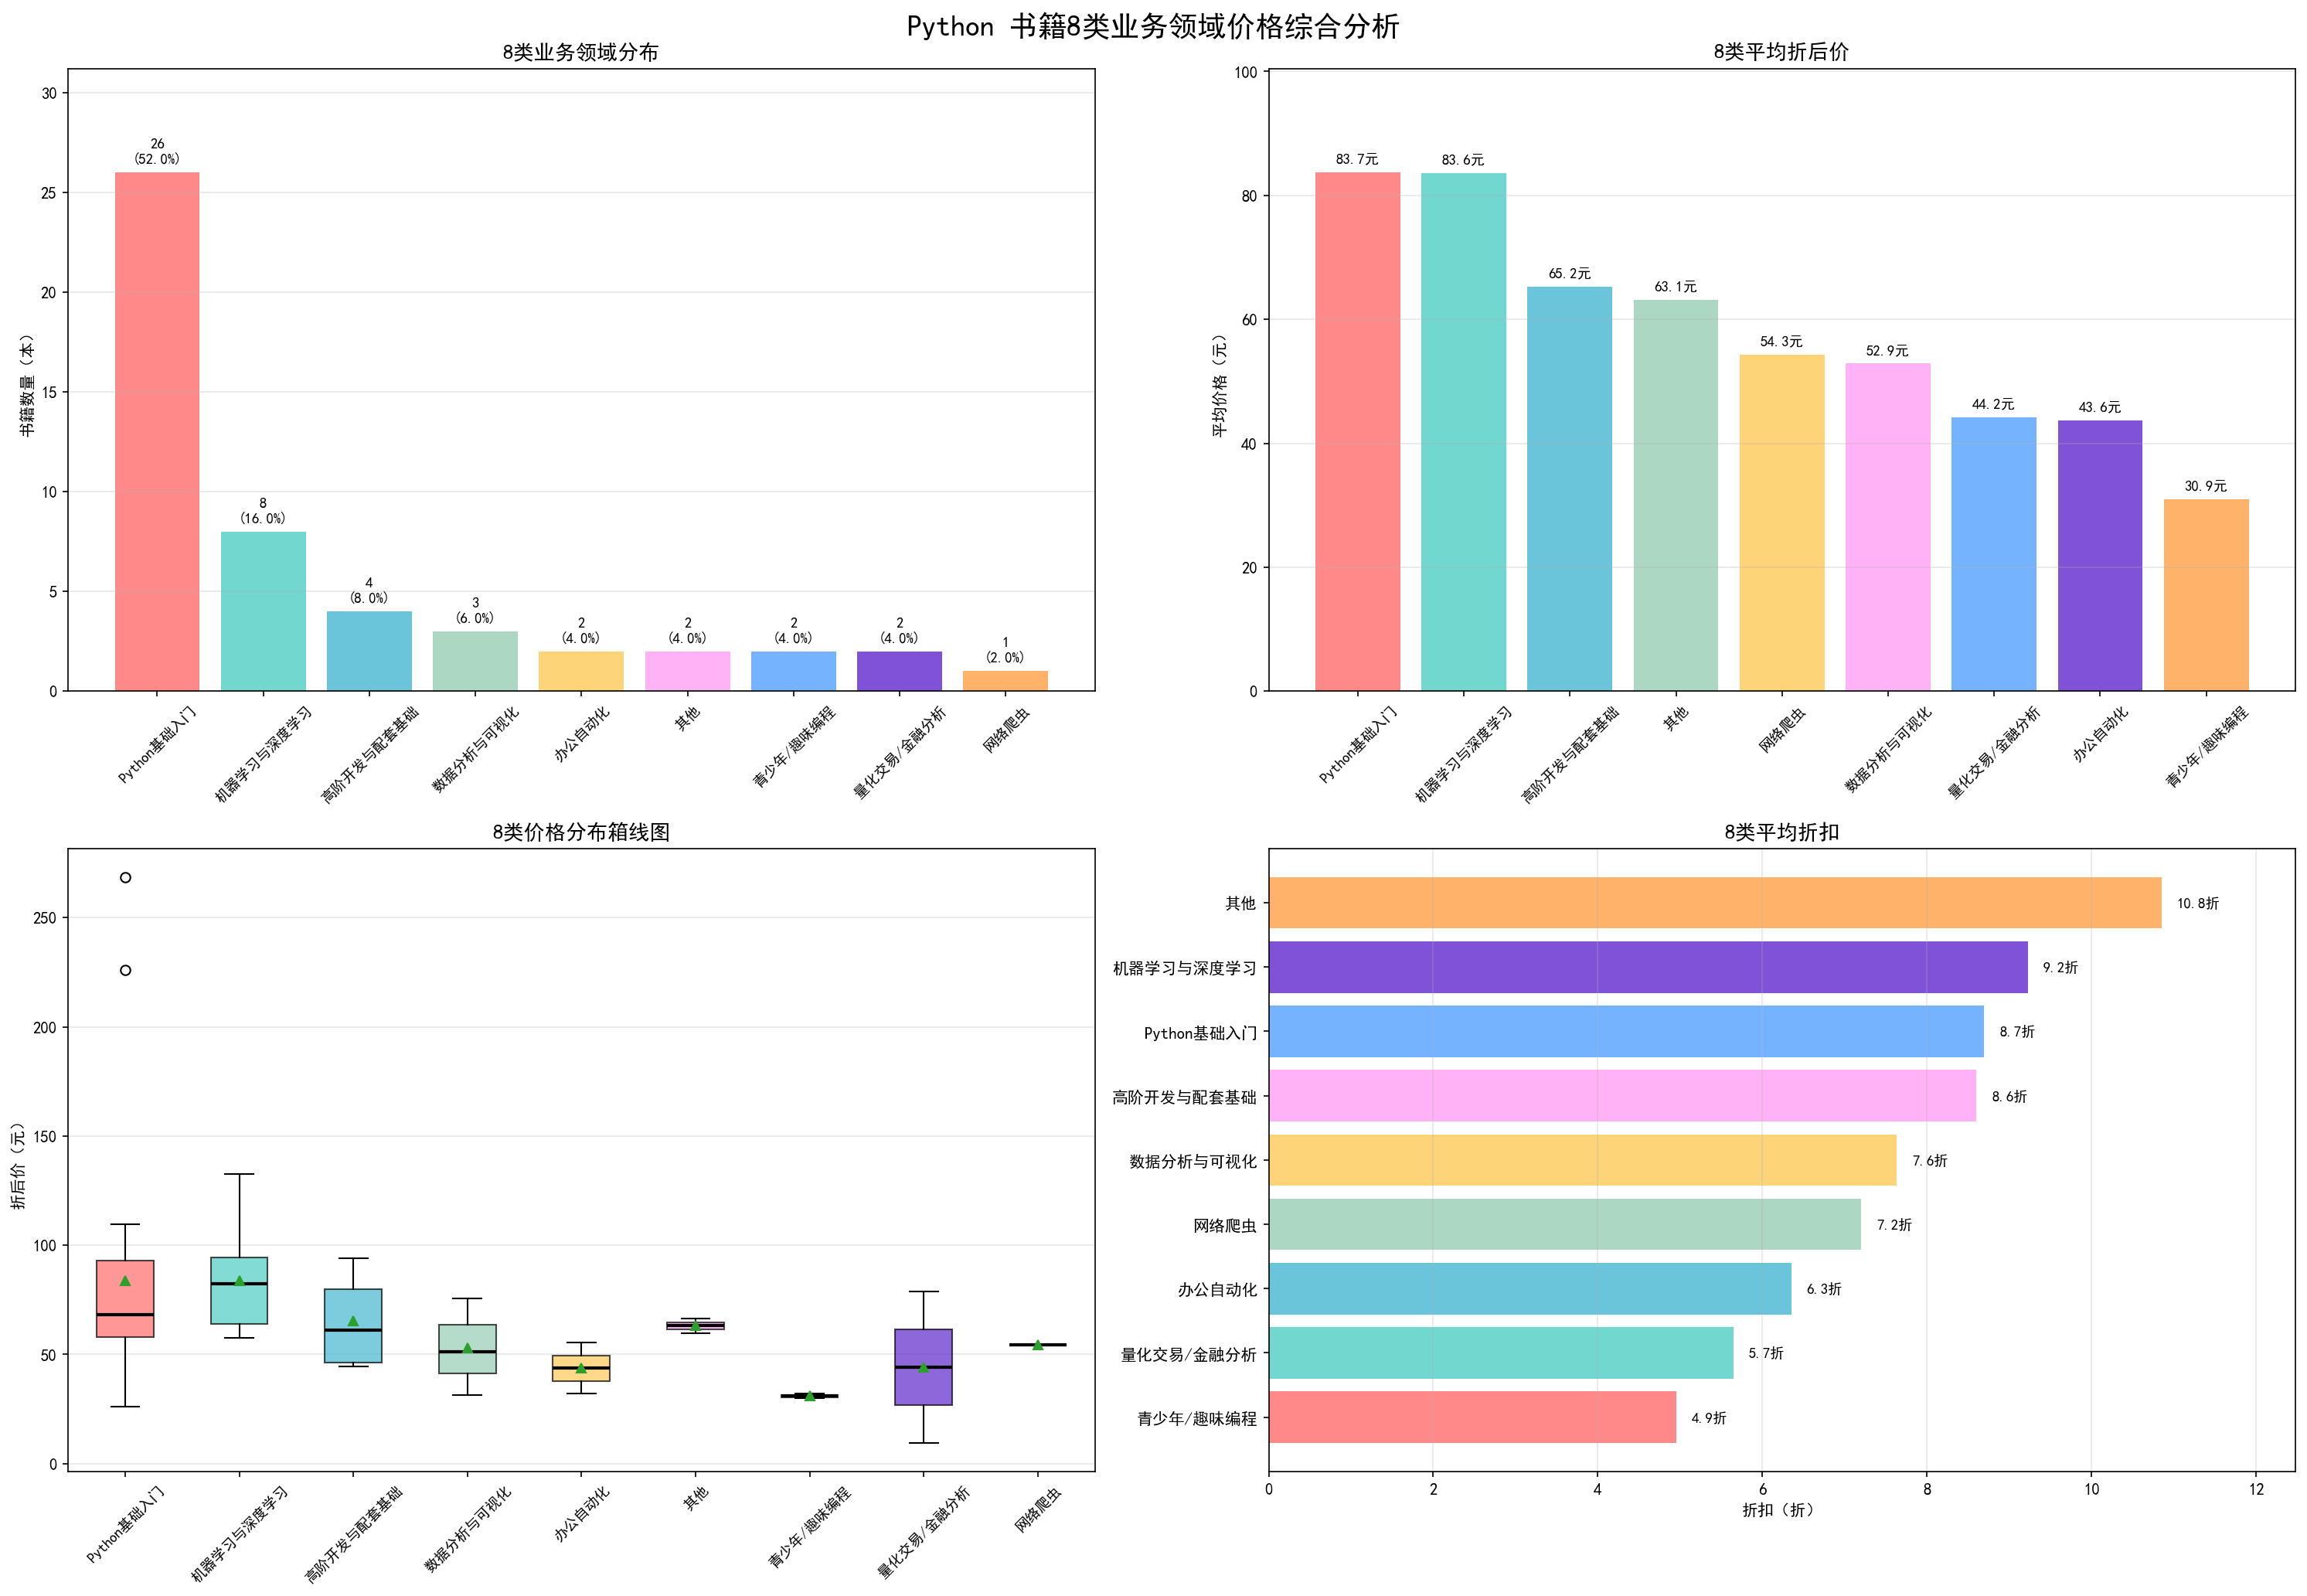

,领域,数量,平均价格,平均折扣,总评论数
0,Python基础入门,26,83.70,8.7,69116
1,机器学习与深度学习,8,83.62,9.2,6033
2,数据分析与可视化,3,52.86,7.6,2167
3,办公自动化,2,43.64,6.4,664
4,量化交易/金融分析,2,44.24,5.6,1822
5,网络爬虫,1,54.26,7.2,20
6,青少年/趣味编程,2,30.94,4.9,2881
7,高阶开发与配套基础,4,65.22,8.6,1156


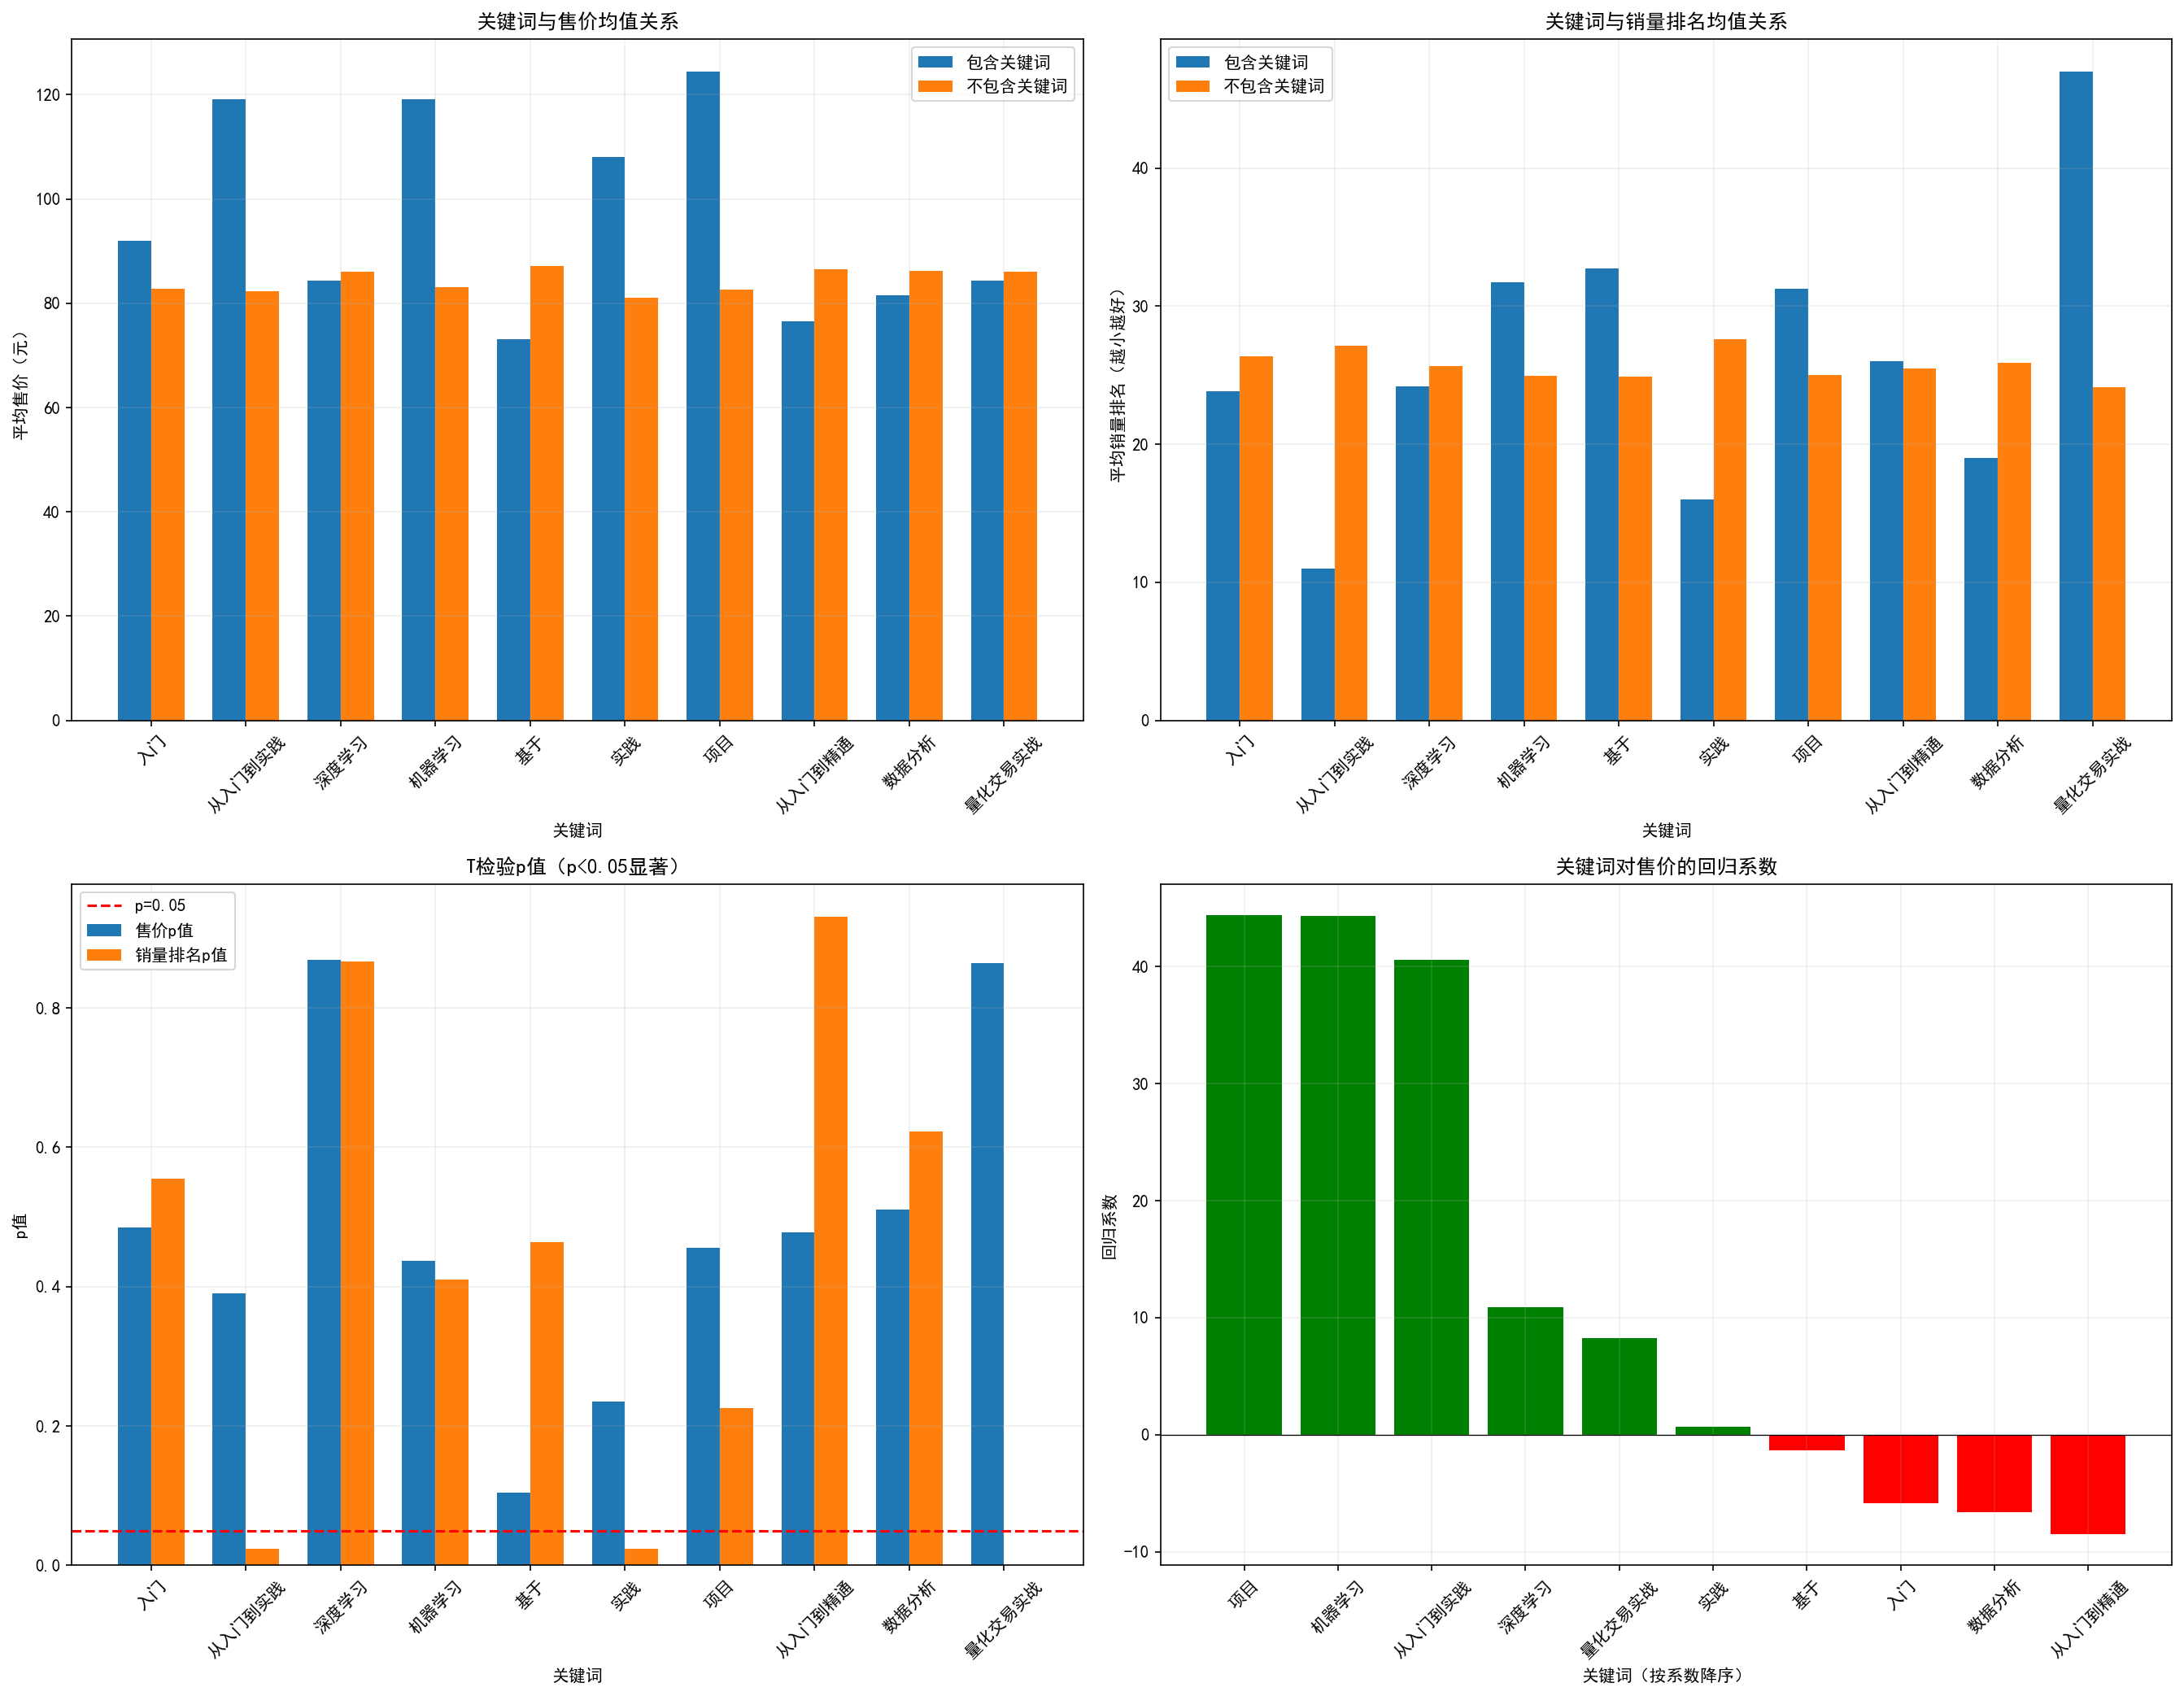

In [ ]:
# ==========================
# 主程序
# 杨金梅25210277
# ==========================

import os
import time
import sys
from io import StringIO
# 新增：用于markdown转html
import markdown

# ========== 修复：Jupyter 兼容路径（不用 __file__） ==========
# 强制固定工作目录，防止被 ipynb 篡改
BASE_DIR = os.path.abspath(".")
os.chdir(BASE_DIR)

# ========== 【修改】创建上级目录的 output 文件夹 ==========
# 保存到【脚本上级目录】的 output 文件夹：..\output\
output_dir = os.path.join(os.pardir, "output")
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# ========== 【新增】日志捕获：保存全部输出到文档（不影响原逻辑） ==========
class LogSaver:
    def __init__(self, log_path=os.path.join(os.pardir, "output/run_output_log.md")):
        self.log_path = log_path
        self.stdout = sys.stdout
        self.buf = StringIO()

    def write(self, data):
        self.stdout.write(data)
        self.buf.write(data)

    def flush(self):
        self.stdout.flush()

    def save(self):
        with open(self.log_path, "w", encoding="utf-8") as f:
            f.write(self.buf.getvalue())
        print(f"\n✅ 全部运行日志已保存至：{self.log_path}")

# 启动日志捕获（全程自动记录）
log_saver = LogSaver()
sys.stdout = log_saver

# ========== 你的原有代码 100% 不变 ==========
def run_notebook_with_separator(filename):
    """运行单个notebook，并打印分隔条"""
    # 打印顶部分隔条 + 文件名
    print("\n" + "="*60)
    print(f"📌 正在执行：{filename}")
    print("="*60 + "\n")
    
    # 执行文件
    get_ipython().run_line_magic('run', f'{filename}')
    
    # 修复：每次执行完强制切回原始目录
    os.chdir(BASE_DIR)
    
    # 短暂停顿让输出更清晰
    time.sleep(0.2)
    
    # 打印底部完成分隔条
    print(f"\n✅ {filename} 执行完成")
    print("-"*60 + "\n")


# ============= 按顺序执行列表 =============
notebook_list = [
    "01_data_download.ipynb",
    "02_data_clean.ipynb",
    "03_analysis_Tsk1.ipynb",
    "03_analysis_Tsk2.ipynb",
    "03_analysis_Tsk3.ipynb",
    "03_analysis_Tsk4.ipynb",
    "03_analysis_Tsk5.ipynb",
    "03_analysis_Tsk6.ipynb",
    "03_analysis_Tsk7.ipynb"
]

# 开始批量执行
for nb_file in notebook_list:
    run_notebook_with_separator(nb_file)

print("\n🎉 所有文件全部执行完毕！")

# ==========================
# 【新增功能】将 analysis.md 转换为 HTML 市场调研报告
# ==========================
print("\n" + "="*60)
print("📄 正在生成市场调研报告HTML...")
print("="*60 + "\n")

try:
    # 从 上级目录 读取 analysis.md
    md_file_path = os.path.join(os.pardir, "analysis.md")
    # 强制保存到：上级目录/output/市场调研报告.html
    html_output_path = os.path.abspath(os.path.join(os.pardir, "output", "市场调研报告.html"))
    
    # 读取markdown文件
    with open(md_file_path, "r", encoding="utf-8") as f:
        md_content = f.read()
    
    # 转换为HTML
    html_content = markdown.markdown(md_content, extensions=['tables', 'fenced_code'])
    
    # 生成完整HTML页面
    full_html = f"""<!DOCTYPE html>
<html lang="zh-CN">
<head>
    <meta charset="UTF-8">
    <title>市场调研报告</title>
    <style>
        body {{ font-family: Microsoft YaHei, Arial; margin: 40px; line-height: 1.6; font-size: 16px; }}
        h1, h2, h3 {{ color: #2c3e50; border-bottom: 2px solid #eee; padding-bottom: 8px; }}
        table {{ border-collapse: collapse; width: 100%; margin: 15px 0; }}
        th, td {{ border: 1px solid #ddd; padding: 10px; text-align: left; }}
        th {{ background-color: #f5f5f5; }}
        code {{ background-color: #f8f9fa; padding: 2px 5px; border-radius: 3px; }}
    </style>
</head>
<body>
    <h1>市场调研报告</h1>
    {html_content}
</body>
</html>"""
    
    # 写入文件
    with open(html_output_path, "w", encoding="utf-8") as f:
        f.write(full_html)
    
    print(f"✅ 市场调研报告生成成功！")
    print(f"📂 保存路径：{html_output_path}")

except Exception as e:
    print(f"❌ 报告生成失败：{str(e)}")
    print("请检查上级目录下的 analysis.md 文件是否存在")

print("\n" + "-"*60 + "\n")

# ========== 自动保存日志 ==========
log_saver.save()
print(f"\n📝 运行日志保存路径：{log_saver.log_path} ")